Dataset Link: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

This dataset is a curated combination of the following publicly available datasets:
- figshare brain MRI dataset
- SARTAJ dataset
- Br35H dataset

The dataset contains 7,200 human brain MRI images categorized into four classes:
- Glioma
- Meningioma
- Pituitary tumor
- No tumor



### Requirements:
- Apply at least 2 filtering techniques
  - Gaussian Filter
  - Median Filter

- Compare results visually and numerically

In [ ]:
from pathlib import Path
import sys

# BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path().resolve().parent

sys.path.append(str(BASE_DIR))

train_path = BASE_DIR / "data" / "raw" / "Training"
test_path = BASE_DIR / "data" / "raw" / "Testing"

In [2]:
from modules.data_loader import load_data
from modules.preprocessing import standardize

X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Apply preprocessing to the loaded data
X_train = [standardize(img) for img in X_train]
X_test = [standardize(img) for img in X_test]

In [3]:
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))
print(X_train[0].shape)

5600 5600
1600 1600
(256, 256)


In [4]:
from collections import Counter

print(Counter(y_train))
print(Counter(y_test))

Counter({'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400})
Counter({'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400})


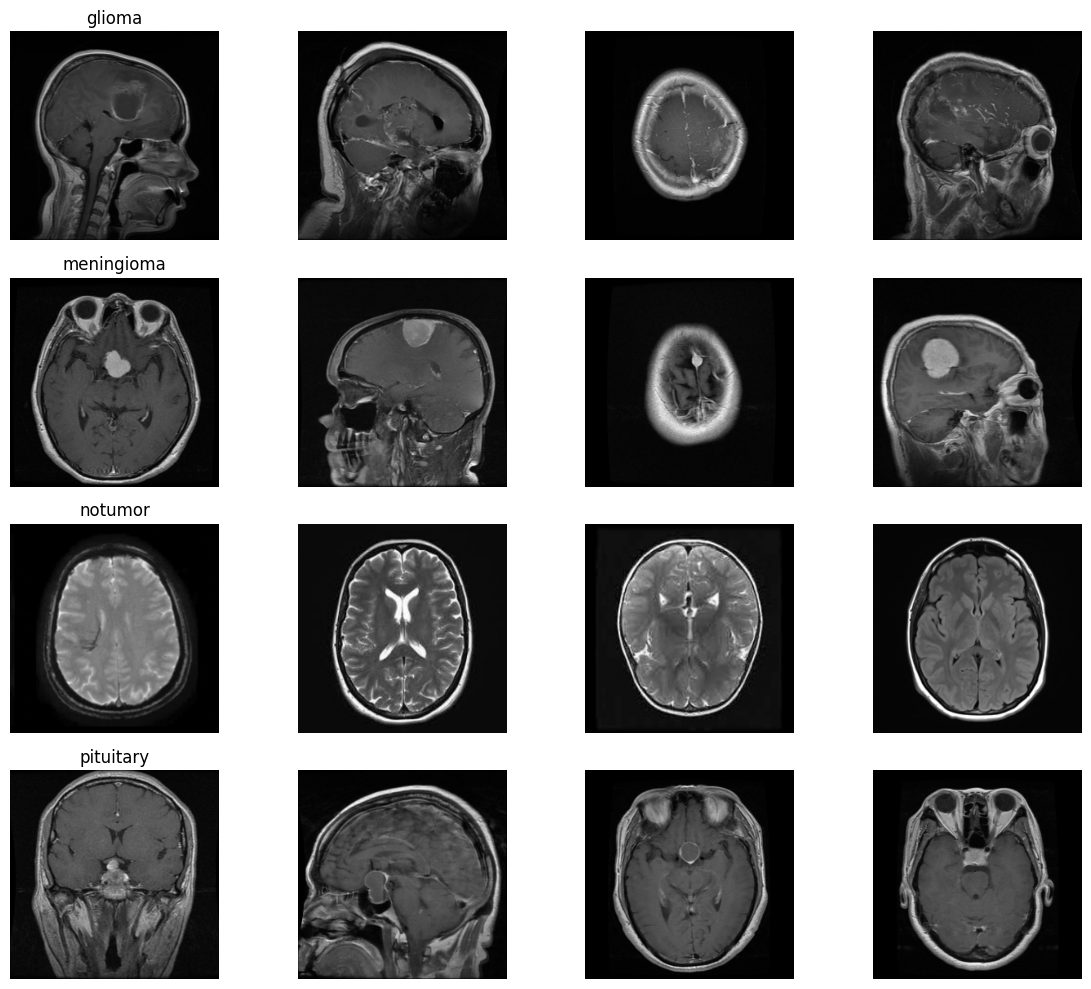

In [5]:
import matplotlib.pyplot as plt
import random
random.seed(42)

classes = sorted(list(set(y_train)))

fig, axes = plt.subplots(len(classes), 4, figsize=(12, 10))

for row, cls in enumerate(classes):
    # get indices for this class
    idxs = [i for i, label in enumerate(y_train) if label == cls]
    random.shuffle(idxs)
    for col in range(4):
        img = X_train[idxs[col]]

        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(cls)

plt.tight_layout()
plt.show()

### Apply filters to a few sample images and visualize results

In [6]:
# Apply filters to a few sample images and visualize results

sample_imgs = X_train[:5]

from modules.preprocessing import gaussian_filter, median_filter

results = []
for img in sample_imgs:
    g_img = gaussian_filter(img)
    m_img = median_filter(img)
    results.append((img, g_img, m_img))



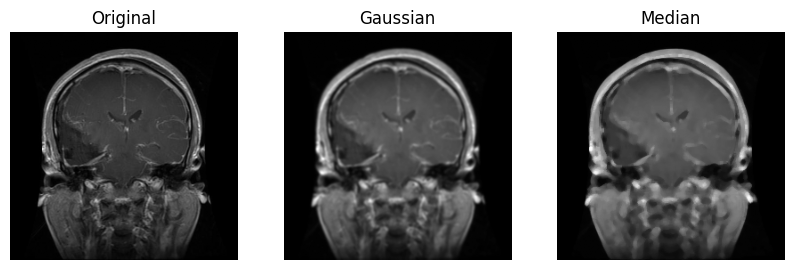

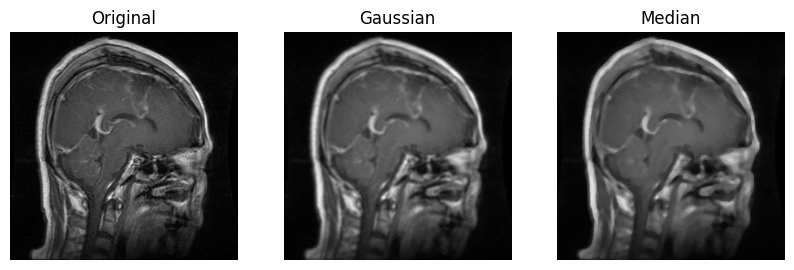

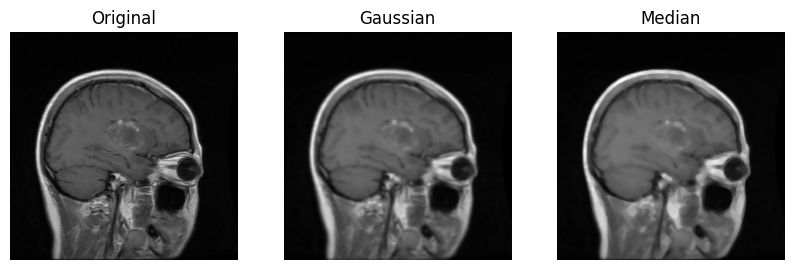

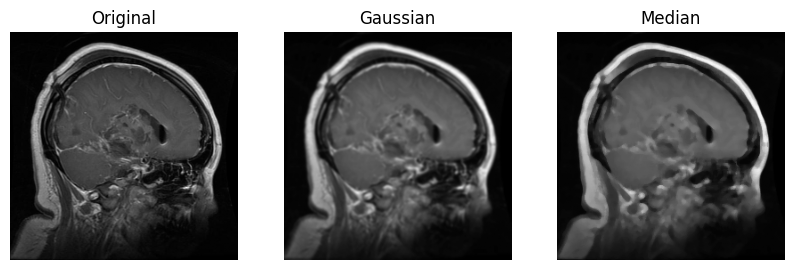

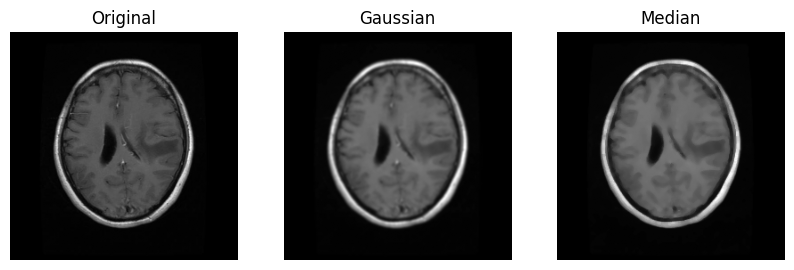

In [7]:
import matplotlib.pyplot as plt

for original, g_img, m_img in results:
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(original, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(g_img, cmap="gray")
    plt.title("Gaussian")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(m_img, cmap="gray")
    plt.title("Median")
    plt.axis("off")

    plt.show()

In [8]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Higher PSNR = less difference from og img (pixel-wise) = better 
# Higher SSIM = better structure preservation to og img = better
# Note: tumor detection depends on: edges, shapes,boundaries and therefore SSIM is more relevant for our task than PSNR which focuses on pixel-wise differences 

for i, (original, g_img, m_img) in enumerate(results):
    print(f"Image {i} Filtering Results:")
    print("Gaussian:")
    print("PSNR:", psnr(original, g_img))
    print("SSIM:", ssim(original, g_img))

    print("Median:")
    print("PSNR:", psnr(original, m_img))
    print("SSIM:", ssim(original, m_img))

    print("-" * 40)

Image 0 Filtering Results:
Gaussian:
PSNR: 31.752539856561942
SSIM: 0.9362785535018304
Median:
PSNR: 29.390070846536844
SSIM: 0.8884306123556969
----------------------------------------
Image 1 Filtering Results:
Gaussian:
PSNR: 31.04667319601919
SSIM: 0.928945063847288
Median:
PSNR: 28.96221763171868
SSIM: 0.8754533335259623
----------------------------------------
Image 2 Filtering Results:
Gaussian:
PSNR: 32.67047093000593
SSIM: 0.9553674917516443
Median:
PSNR: 30.93171686216936
SSIM: 0.9257357185703255
----------------------------------------
Image 3 Filtering Results:
Gaussian:
PSNR: 31.313236429875573
SSIM: 0.923473030580554
Median:
PSNR: 29.775576687047046
SSIM: 0.8731795522537505
----------------------------------------
Image 4 Filtering Results:
Gaussian:
PSNR: 34.47547875814309
SSIM: 0.9730814468816297
Median:
PSNR: 33.62220981230648
SSIM: 0.9629308189433102
----------------------------------------


#### Gaussian filtering provided better overall results for this dataset. It achieved higher PSNR and better SSIM, while preserving important structural details. Since MRI noise is typically smooth rather than impulse-based, Gaussian filtering is more suitable than median filtering for this application.